### Human In The Loop

In [ ]:
import os
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq: llama-3.1-8b-instant")

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022F779C3010>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022F77B17610>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import add_messages # Reducers
from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode, tools_condition

# New lib
from langgraph.types import Command, interrupt 
# Interrupt : forcefully interrpting the flow so human can provide feedback

memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool 
def human_assistant(query: str) -> str:
    """"reqeust assistance from a human"""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistant]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution
    # we disabled parallel tool calling to avoid repeating any
    # tool invocations when we resume
    return {"messages": message}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", tools_condition)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")



graph = graph_builder.compile(checkpointer=memory)

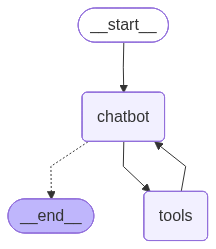

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
user_input = "I need some expert guidance and assistance for bilding AI agent. Could you please provide assistance for me?"

config = {"configurable": {"thread_id": "1"}}

events = graph.stream({"messages": user_input}, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

# Now it will stop here (The flow stops here) : Interrupted
# Now it is expecting Human should provide some input back

================================ Human Message =================================

I need some expert guidance and assistance for bilding AI agent. Could you please provide assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistant (x2a32v0rx)
 Call ID: x2a32v0rx
  Args:
    query: expert guidance and assistance for building AI agent
================================== Ai Message ==================================
Tool Calls:
  human_assistant (x2a32v0rx)
 Call ID: x2a32v0rx
  Args:
    query: expert guidance and assistance for building AI agent


In [ ]:
human_response = "We, the experts are here to help! we'd recommand you check out langgraph. It is a great framework for building AI agents. You can also check out the documentation and the examples to get started."

# to execute this message
# we use 'Command' to resume the flow

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

# Now it is not interrupted


================================== Ai Message ==================================
Tool Calls:
  human_assistant (x2a32v0rx)
 Call ID: x2a32v0rx
  Args:
    query: expert guidance and assistance for building AI agent
================================= Tool Message =================================
Name: human_assistant

We, the experts are here to help! we'd recommand you check out langgraph. It is a great framework for building AI agents. You can also check out the documentation and the examples to get started.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rd5n1yg11)
 Call ID: rd5n1yg11
  Args:
    query: building AI agent langgraph
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "building AI agent langgraph", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/pythoneers/building-ai-agent-systems